# Iris Flower Classification using Machine Learning

## Project Overview

This project focuses on classifying Iris flowers into three species:

- Iris Setosa
- Iris Versicolor
- Iris Virginica

The classification is performed using four physical measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Multiple machine learning classification algorithms are trained and evaluated to determine their performance on the Iris dataset.

## Objective

The objective of this project is to build a machine learning model that can accurately predict the species of an Iris flower based on its physical measurements.

## Machine Learning Models

The following classification algorithms are evaluated:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest

## Evaluation Metrics

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- 5-Fold Cross-Validation

## Technology Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook
> Train a model to identify the species of an iris flower from its physical measurements.


## 1. Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, model training, hyperparameter tuning, and model evaluation.

In [1]:
#-------------- DATA MANUPLIATION --------------
import pandas as pd
import  numpy as np

# --------------DATA VISULAIZATION --------------
import matplotlib.pyplot as plt
import seaborn as sns

# --------------LOAD DATASET--------------
from sklearn.datasets import load_iris

# --------------ML PIPELINE AND PREPROCESSING--------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,RobustScaler

# --------------DATA SPLITTING AND CROSS VALIDATION--------------
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV

# --------------MACHINE LEARING MODELS--------------
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

#--------------EVALUTION METRICS--------------
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,roc_auc_score,f1_score

## 2. Load the Iris Dataset

The Iris dataset is directly available in scikit-learn, so no external download is required.

The dataset contains measurements of Iris flowers belonging to three different species.

In [2]:
#--------------LOAD DATASET--------------
data=load_iris()

In [3]:
#--------------DISPLAY AVAILABLE INFORMATION--------------
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
#--------------CREATE DATAFRAME--------------
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

#--------------ADD TARGET VARIABLE--------------
df["target"] = data.target

#--------------ADD SPECIES--------------
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

## 3. Dataset Overview

Before building machine learning models, the dataset is inspected to understand:

- Number of observations and features
- Data types
- Missing values
- Statistical distribution
- Target class distribution

In [5]:
#--------------FIRST FIVE RECORDS--------------
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  Setosa  
1       0  Setosa  
2       0  Setosa  
3       0  Setosa  
4       0  Setosa  


In [6]:
#--------------DATASET SHAPE--------------
print(df.shape)

(150, 6)


In [7]:
#--------------DATASET INFORMATION--------------
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 8.4 KB
None


In [8]:
#--------------STATISTICAL SUMMARY--------------
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [9]:
#--------------MISSING VALUE--------------
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [10]:
#--------------CLASS DISTRIPUTION--------------
print(df["species"].value_counts())

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


## 4. Define Features and Target

The four flower measurements are used as input features, while the Iris species is the target variable.

The target column is not included among the input features because it represents the value that the model needs to predict.

In [11]:
#----------DEFINE INPUT FEATURE----------------
x= df[data.feature_names]

#----------DEFINE TARGET--------------
y = df["target"]

print("Feature shape:", x.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, distribution, relationships, and patterns present in the dataset.

The analysis is divided into three parts:

1. **Univariate Analysis** – Analysis of individual variables.
2. **Bivariate Analysis** – Analysis of relationships between two variables.
3. **Multivariate Analysis** – Analysis involving multiple variables simultaneously.

These analyses help identify feature distributions, class differences, relationships between features, and potentially important features for classification.

In [12]:
#--------------SEPERATE NUMERICAL AND CATEGORICAL FEATURE--------------
num_data=df.select_dtypes(include="float64").columns.str.strip()
cat_data=df.select_dtypes(include="str").columns.str.strip()

In [13]:
df.skew(numeric_only=True)

sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
target               0.000000
dtype: float64

In [14]:
df.kurt(numeric_only=True)

sepal length (cm)   -0.552064
sepal width (cm)     0.228249
petal length (cm)   -1.402103
petal width (cm)    -1.340604
target              -1.510135
dtype: float64

In [15]:
df.corr(numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


## 5.1 Univariate Analysis

Univariate means:

>Analyzing one variable at a time.

For Iris, we can analyze:

-  Distribution of each numerical feature
-  Box plots
-  Target/species distribution

### 5.1.1 Distribution of Numerical Features

Histograms with KDE curves are used to understand the distribution of each numerical feature.

They help identify the center, spread, shape, and possible skewness of the feature distributions.

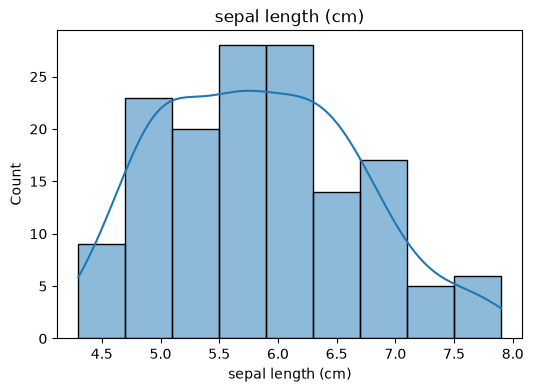

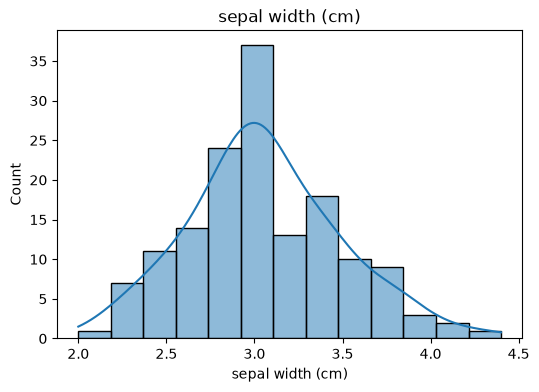

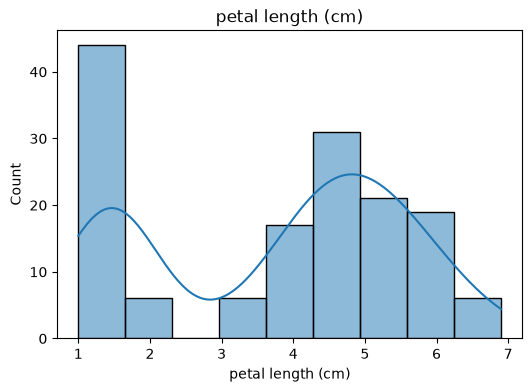

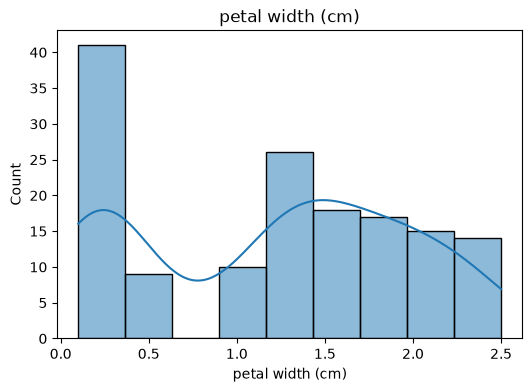

In [16]:
#--------------FEATURE DISSTRIBUTION---------------
for num in num_data:
    plt.figure(figsize=(6,4))
    sns.histplot(x=num,kde=True,data=df)
    plt.title(f"{num}")
    plt.show()
    

### 5.1.2 Box Plot Analysis

Box plots are used to examine the distribution and spread of numerical features.

They help identify:

- Median
- Quartiles
- Interquartile range
- Potential outliers
- Overall variability

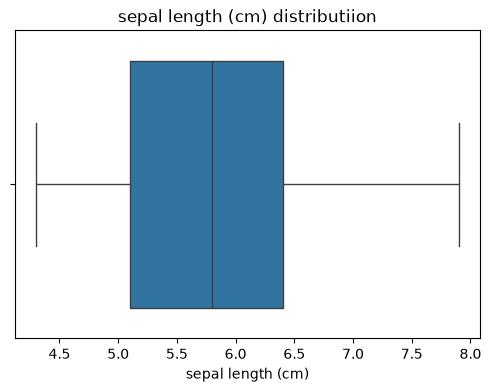

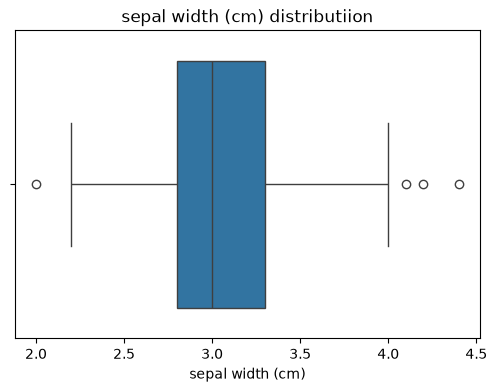

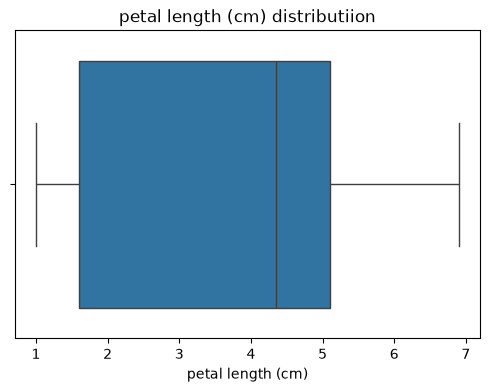

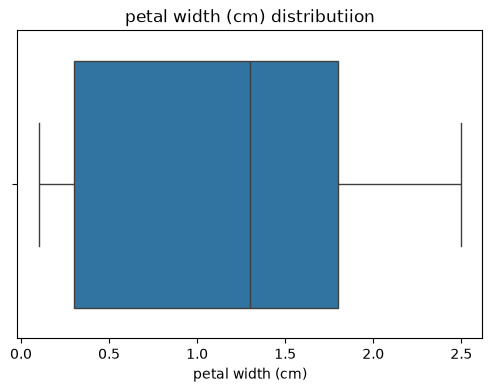

In [17]:
#------------OUTLIER DETECTION-----------
for num in num_data:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=num,data=df)
    plt.title(f"{num} distributiion")
    

### 5.1.3 Target Class Distribution

The distribution of the target classes is analyzed to determine whether the dataset is balanced.

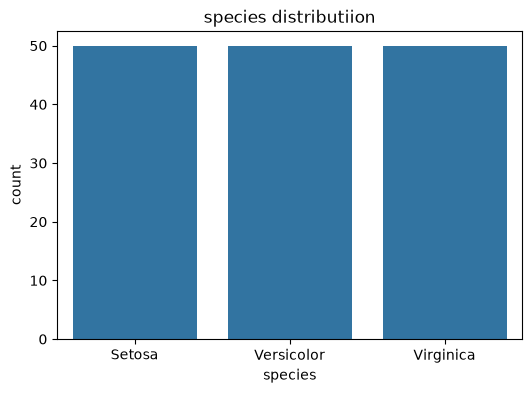

In [18]:
#-----------TARGET DISTRIBUTION------------------
for cat in cat_data:
    plt.figure(figsize=(6,4))
    sns.countplot(x=cat,data=df)
    plt.title(f"{cat} distributiion")
    plt.show()
    

### 5.2 Bivariate Analysis

Bivariate means:

>Analyzing the relationship between two variables.

For Iris, the most useful approach is to examine:

- **Numerical feature vs numerical feature**
- **Numerical feature vs species**

### 5.2.1 Relationship Between Numerical Features

Scatter plots are used to examine relationships between pairs of numerical features.

This helps identify whether different Iris species form distinct groups based on their measurements.

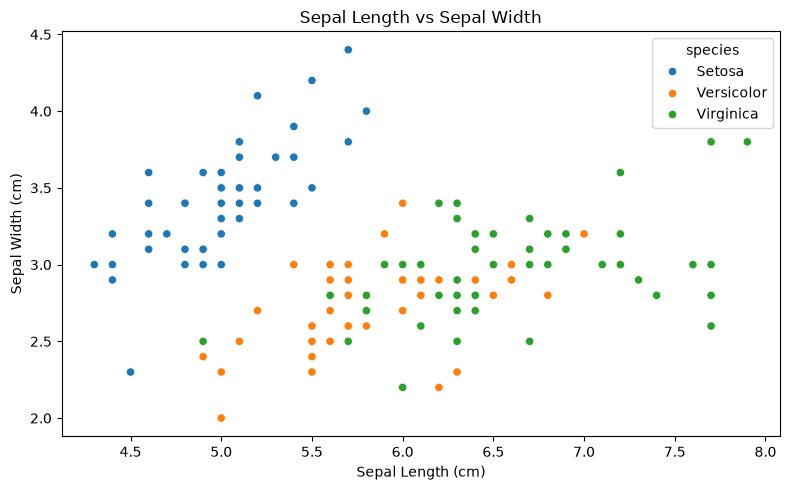

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species"
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.tight_layout()
plt.show()

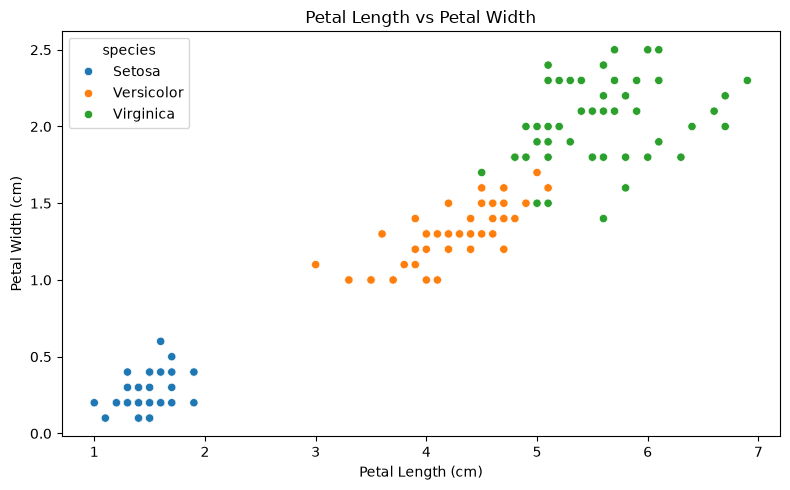

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.tight_layout()
plt.show()

### 5.2.2 Feature Distribution Across Species

Box plots are used to compare the distribution of each numerical feature across the three Iris species.

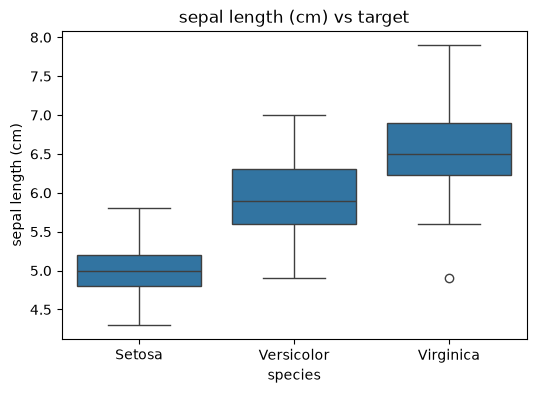

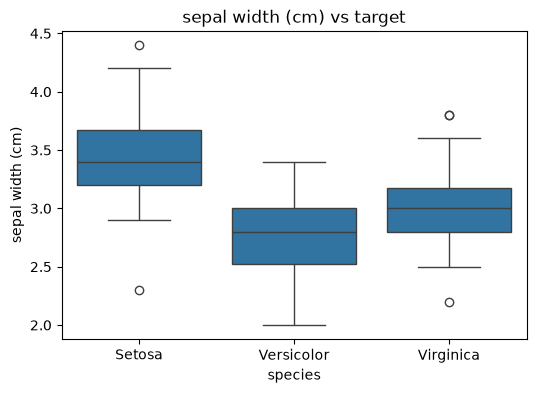

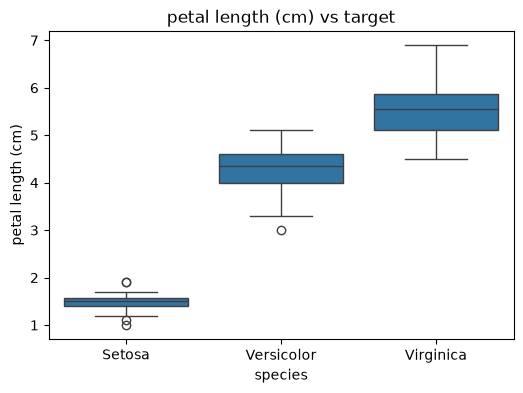

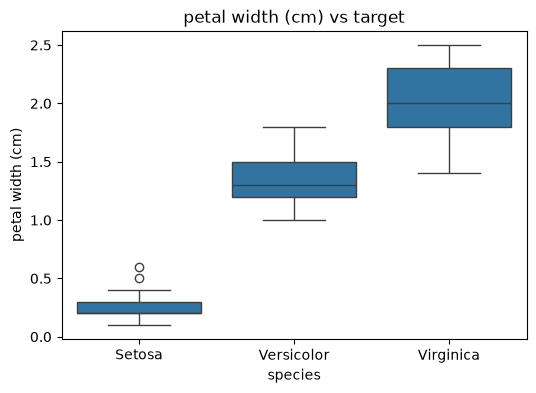

In [21]:
for num in num_data:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=cat,y=num,data=df)
    plt.title(f"{num} vs target")

## 5.3 Multivariate Analysis

Multivariate means:

>Analyzing three or more variables together.

This is especially important for your Iris project because classification depends on multiple flower measurements simultaneously.

### 5.3.1 Pairwise Relationship Analysis

A pair plot is used to visualize the relationships between all numerical features simultaneously.

The target species is used to distinguish the observations by class.

This visualization helps identify:

- Relationships between features
- Class separation
- Feature combinations that may be useful for classification
- Overlapping regions between classes

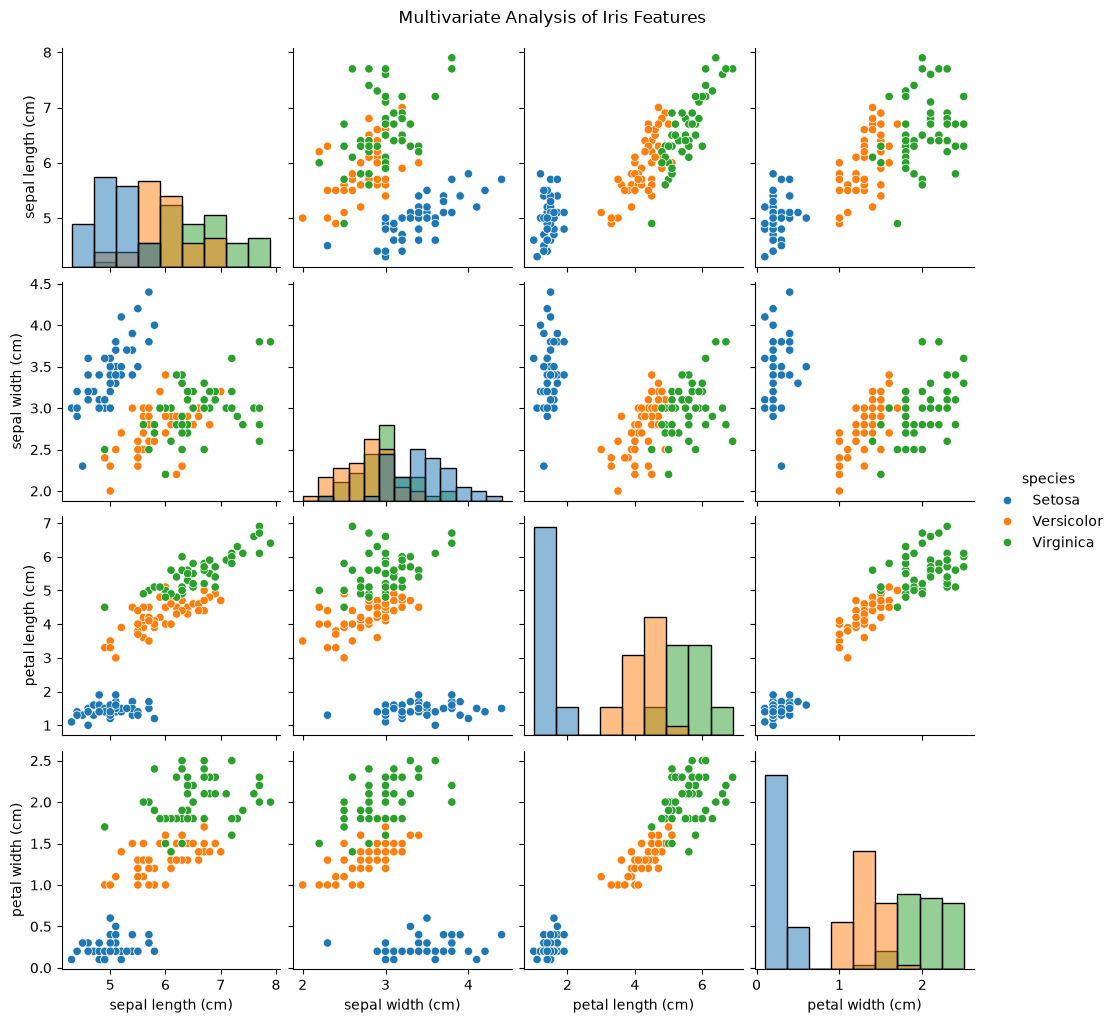

In [22]:
sns.pairplot(
    df,
    vars=num_data,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Multivariate Analysis of Iris Features",
    y=1.02
)

plt.show()

### 5.3.2 Feature Correlation Analysis

A correlation heatmap is used to understand the linear relationships among the numerical features.

Correlation values range from -1 to +1:

- +1 indicates a strong positive relationship.
- 0 indicates little or no linear relationship.
- -1 indicates a strong negative relationship.

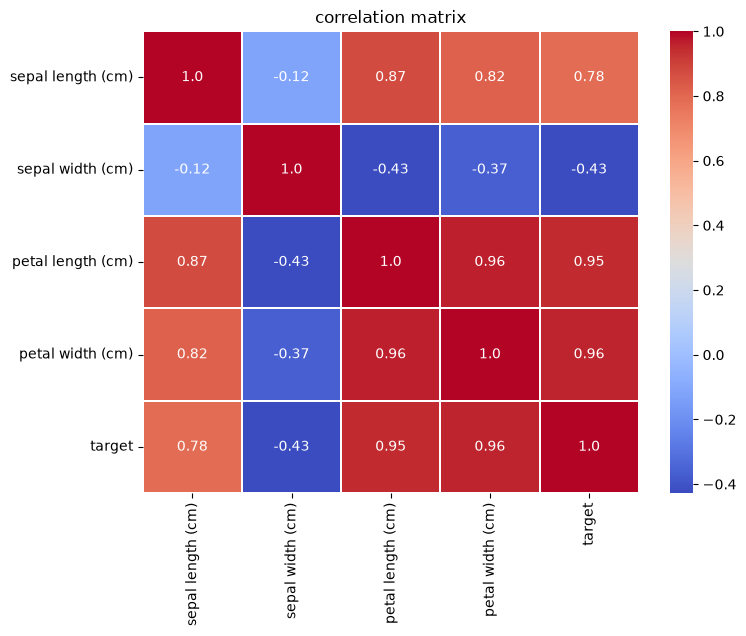

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2",linewidth=0.2)
plt.title("correlation matrix")
plt.show()

## 6. Feature Selection

Feature selection is the process of identifying the input features that provide useful information for predicting the target variable.

Based on the EDA, petal length and petal width show strong separation among the three Iris species. However, the sepal features also contain useful information.

Therefore, all four original features are retained for the initial model training.

### Selected Features

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

No features are removed at this stage because the dataset is small, clean, and contains only four meaningful input features.

In [24]:
# -----------DISPLAY THE SELECTED FEATURE------------------- 
selected_features = data.feature_names

print("Selected Features:")
for feature in selected_features:
    print(" =>", feature)

Selected Features:
 => sepal length (cm)
 => sepal width (cm)
 => petal length (cm)
 => petal width (cm)


## 7. Train-Test Split

The dataset is divided into training and testing subsets.

- **Training set:** Used to train the machine learning models.
- **Testing set:** Used to evaluate the models on unseen data.

An 80:20 split is used, where 80% of the data is used for training and 20% for testing.

Stratification is applied to preserve the proportion of each Iris species in both datasets.

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [26]:
print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

x_train shape: (120, 4)
x_test shape : (30, 4)
y_train shape: (120,)
y_test shape : (30,)


### 7.1 Verify Class Distribution

This is a good professional practice because we used **stratify=y**.

In [27]:
print("Training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training class distribution:
target
0    40
1    40
2    40
Name: count, dtype: int64

Testing class distribution:
target
0    10
1    10
2    10
Name: count, dtype: int64


## 8. Feature Scaling

Feature scaling transforms numerical features to a comparable scale.

Scaling is particularly important for distance-based and optimization-based algorithms such as:

- K-Nearest Neighbors
- Logistic Regression

Decision Trees and Random Forests generally do not require feature scaling because their decisions are based on feature thresholds rather than distances.

A Pipeline will be used for models that require scaling. This ensures that the scaler is fitted only on the training data and helps prevent data leakage.

## 9. Baseline Model Training

Four classification algorithms are selected for the initial comparison:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest

The baseline models are evaluated before hyperparameter tuning.

In [28]:
models={
    "LOGISTICREGRESSION":Pipeline([
        #("scaler",RobustScaler()),
        ("model",LogisticRegression(random_state=42,max_iter=200))
    ]),
    "KNN":Pipeline([
        #("scaler",RobustScaler()),
        ("model",KNeighborsClassifier(n_neighbors=5))
    ]),
    "DECISIONTREE":Pipeline([
        ("model",DecisionTreeClassifier(random_state=42,max_depth=5,min_samples_split=10))
    ]),
    "RANDOMFOREST":Pipeline([
        ("model",RandomForestClassifier(random_state=42,n_estimators=100,max_depth=5))
    ])
}

## 10. Baseline Model Evaluation

The trained models are evaluated using the following metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Since Iris is a multiclass classification problem, macro averaging is used for Precision, Recall, and F1-Score.

Macro averaging gives equal importance to all three Iris species.

In [29]:
model_res=[]
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    y_prob=model.predict_proba(x_test)
    train_score=model.score(x_train,y_train)
    test_score=model.score(x_test,y_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred,average="macro")
    recall=recall_score(y_test,y_pred,average="macro")
    f1=f1_score(y_test,y_pred,average="macro")
    roc_auc=roc_auc_score(y_test,y_prob,average="macro",multi_class="ovr")
    cv_scores=cross_val_score(model,x_train,y_train,cv=5,scoring="f1_macro")
    model_res.append([name,train_score,test_score,accuracy,precision,recall,f1,roc_auc,cv_scores.mean(),cv_scores.std()])

## 11. Cross-Validation

Five-fold cross-validation is used to obtain a more reliable estimate of model performance.

The training data is divided into five folds. In each iteration:

- Four folds are used for training.
- One fold is used for validation.
- The process is repeated five times.

The mean and standard deviation of the F1-macro score are reported.

In [30]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    scores = cross_val_score(
        model,
        x,
        y,
        cv=5,
        scoring="accuracy"
    )

    print(
        name,
        "Mean Accuracy:",
        scores.mean(),
        "Std:",
        scores.std()
    )

LOGISTICREGRESSION Mean Accuracy: 0.9733333333333334 Std: 0.02494438257849294
KNN Mean Accuracy: 0.9733333333333334 Std: 0.02494438257849294
DECISIONTREE Mean Accuracy: 0.9666666666666668 Std: 0.02108185106778919
RANDOMFOREST Mean Accuracy: 0.9666666666666668 Std: 0.02108185106778919


In [31]:
models_data=pd.DataFrame(model_res,columns=["NAME","TRAIN_SCORE","TEST_SCORE","ACCURACY","PRECISION","RECALL","F1","ROC_AUC","CV_MEAN","CV_STD"])
models_data

,NAME,TRAIN_SCORE,TEST_SCORE,ACCURACY,PRECISION,RECALL,F1,ROC_AUC,CV_MEAN,CV_STD
0,LOGISTICREGRESSION,0.975000,0.966667,0.966667,0.969697,0.966667,0.966583,1.000000,0.966536,0.016732
1,KNN,0.966667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.974967,0.033350
2,DECISIONTREE,0.983333,0.966667,0.966667,0.969697,0.966667,0.966583,0.971667,0.932739,0.020770
3,RANDOMFOREST,1.000000,0.933333,0.933333,0.933333,0.933333,0.933333,0.986667,0.949605,0.017130


## 12. Hyperparameter Tuning

Hyperparameter tuning is performed to find the best combination of
hyperparameters for each machine learning model.

GridSearchCV is used with 5-fold cross-validation and **macro F1-score**
as the evaluation metric. Macro F1-score is suitable for the multiclass
Iris classification problem because it gives equal importance to each
Iris species.

The following models are tuned:

- K-Nearest Neighbors (KNN)
- Logistic Regression
- Decision Tree
- Random Forest

In [32]:
knn_pipeline = Pipeline([
    ("model", KNeighborsClassifier())
])

knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

In [38]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500, random_state=42))
])

logistic_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs"]
}

In [34]:
dt_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_params = {
    "model__max_depth": [2, 3, 4, 5, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [35]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 3, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

In [39]:
grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

grid_logistic = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

grid_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=1
)

In [40]:
grid_knn.fit(x_train, y_train)
grid_logistic.fit(x_train, y_train)
grid_dt.fit(x_train, y_train)
grid_rf.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 3, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.

# 13. Tuned Model Evaluation

After hyperparameter tuning, the best estimator from each model is evaluated
on the unseen test dataset.

The models are compared using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

This evaluation helps determine how well the tuned models perform on unseen
data.

In [41]:
print("Best KNN Parameters:")
print(grid_knn.best_params_)

print("\nBest Logistic Regression Parameters:")
print(grid_logistic.best_params_)

print("\nBest Decision Tree Parameters:")
print(grid_dt.best_params_)

print("\nBest Random Forest Parameters:")
print(grid_rf.best_params_)

Best KNN Parameters:
{'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'uniform'}

Best Logistic Regression Parameters:
{'model__C': 10, 'model__solver': 'lbfgs'}

Best Decision Tree Parameters:
{'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Best Random Forest Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 50}


In [42]:
print("KNN Best CV F1:", grid_knn.best_score_)
print("Logistic Regression Best CV F1:", grid_logistic.best_score_)
print("Decision Tree Best CV F1:", grid_dt.best_score_)
print("Random Forest Best CV F1:", grid_rf.best_score_)

KNN Best CV F1: 0.9749673202614378
Logistic Regression Best CV F1: 0.9663367569249923
Decision Tree Best CV F1: 0.9413040771864303
Random Forest Best CV F1: 0.9581699346405228


In [43]:
tuned_models = {
    "KNN": grid_knn,
    "Logistic Regression": grid_logistic,
    "Decision Tree": grid_dt,
    "Random Forest": grid_rf
}

for name, model in tuned_models.items():
    best_index = model.best_index_
    
    cv_mean = model.cv_results_["mean_test_score"][best_index]
    cv_std = model.cv_results_["std_test_score"][best_index]
    
    print(f"\n{name}")
    print("-" * 40)
    print("Best Parameters:", model.best_params_)
    print("CV Mean F1:", cv_mean)
    print("CV Std:", cv_std)


KNN
----------------------------------------
Best Parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'uniform'}
CV Mean F1: 0.9749673202614378
CV Std: 0.03334973324617602

Logistic Regression
----------------------------------------
Best Parameters: {'model__C': 10, 'model__solver': 'lbfgs'}
CV Mean F1: 0.9663367569249923
CV Std: 0.03162306668752773

Decision Tree
----------------------------------------
Best Parameters: {'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
CV Mean F1: 0.9413040771864303
CV Std: 0.02066060716917218

Random Forest
----------------------------------------
Best Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 50}
CV Mean F1: 0.9581699346405228
CV Std: 1.1102230246251565e-16


In [44]:
final_models = {
    "KNN": grid_knn.best_estimator_,
    "Logistic Regression": grid_logistic.best_estimator_,
    "Decision Tree": grid_dt.best_estimator_,
    "Random Forest": grid_rf.best_estimator_
}

In [45]:
predictions = {}

for name, model in final_models.items():
    model.fit(x_train, y_train)
    predictions[name] = model.predict(x_test)

In [66]:
final_results = []

for name, model in final_models.items():

    y_pred = model.predict(x_test)
    
    # Probability prediction for ROC-AUC
    y_prob = model.predict_proba(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="macro"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    final_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

[['KNN', 1.0, 1.0, 1.0, 1.0, 1.0],
 ['Logistic Regression', 1.0, 1.0, 1.0, 1.0, 1.0],
 ['Decision Tree',
  0.9333333333333333,
  0.9333333333333332,
  0.9333333333333332,
  0.9333333333333332,
  0.9733333333333333],
 ['Random Forest',
  0.9666666666666667,
  0.9696969696969697,
  0.9666666666666667,
  0.9665831244778612,
  0.9866666666666667]]

In [89]:
final_results_df = pd.DataFrame(
    final_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

final_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KNN,1.000000,1.000000,1.000000,1.000000,1.000000
1,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
2,Decision Tree,0.933333,0.933333,0.933333,0.933333,0.973333
3,Random Forest,0.966667,0.969697,0.966667,0.966583,0.986667


In [47]:
train_test_results = []

for name, model in final_models.items():

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_test_results.append([
        name,
        train_accuracy,
        test_accuracy
    ])

train_test_df = pd.DataFrame(
    train_test_results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy"
    ]
)

train_test_df

,Model,Train Accuracy,Test Accuracy
0,KNN,0.966667,1.000000
1,Logistic Regression,0.975000,1.000000
2,Decision Tree,0.991667,0.933333
3,Random Forest,0.983333,0.966667


In [48]:
from sklearn.metrics import classification_report

for name, model in final_models.items():

    y_pred = model.predict(x_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=data.target_names
        )
    )

KNN
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90    

## 14. Confusion Matrix

A confusion matrix is used to analyze the classification performance of each
tuned model.

The matrix shows the number of correctly and incorrectly classified samples
for each Iris species.

- The diagonal values represent correctly classified samples.
- The off-diagonal values represent misclassified samples.

Confusion matrices are generated for all four tuned models.

In [90]:
for name, model in final_models.items():

    y_pred = model.predict(x_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)


KNN
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Logistic Regression
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Decision Tree
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Random Forest
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [ ]:
for name, model in final_models.items():

    y_pred = model.predict(x_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=data.target_names,
        yticklabels=data.target_names
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

In [ ]:
for name, model in final_models.items():

    y_pred = model.predict(x_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        normalize="true"
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=data.target_names,
        yticklabels=data.target_names
    )

    plt.title(f"Normalized Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

## 15. Classification Report

The classification report provides detailed performance metrics for each Iris
species.

The report includes:

- Precision
- Recall
- F1-score
- Support

Macro-averaged metrics are used when comparing the overall performance of the
multiclass classification models.

In [ ]:
from sklearn.metrics import classification_report

for name, model in final_models.items():

    y_pred = model.predict(x_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=data.target_names
        )
    )

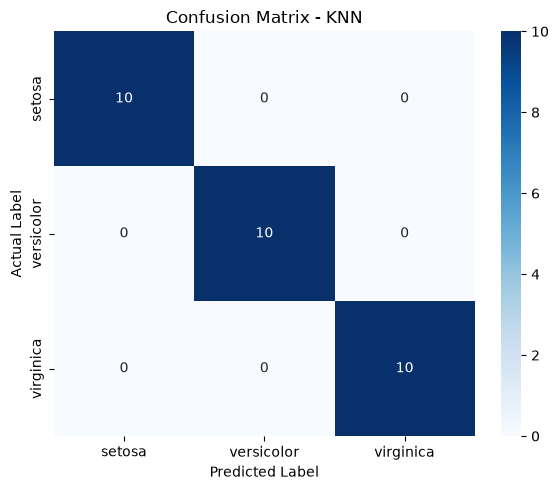

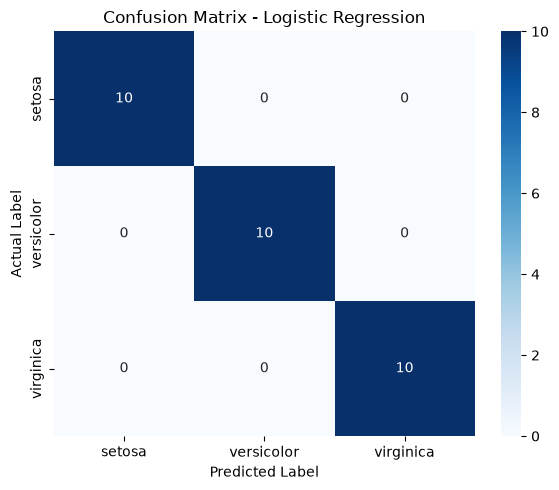

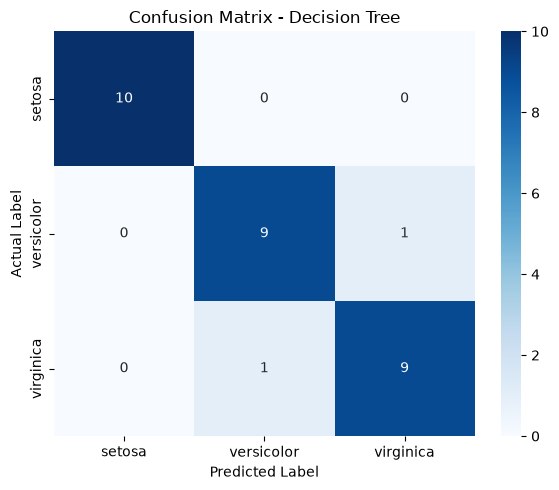

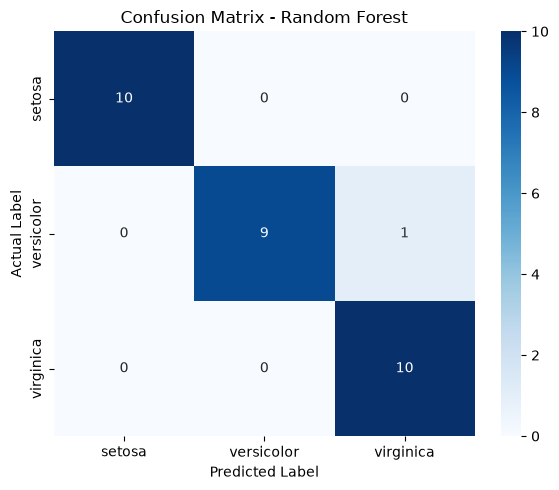

In [50]:
for name, model in final_models.items():

    y_pred = model.predict(x_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=data.target_names,
        yticklabels=data.target_names
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

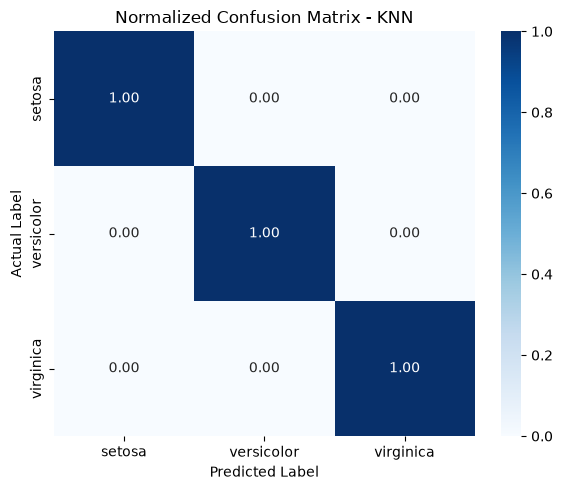

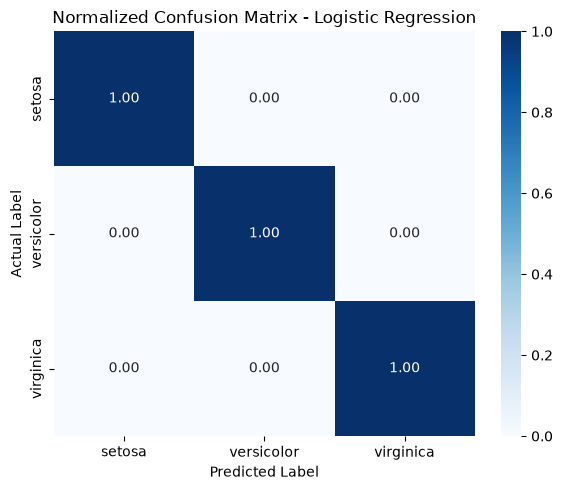

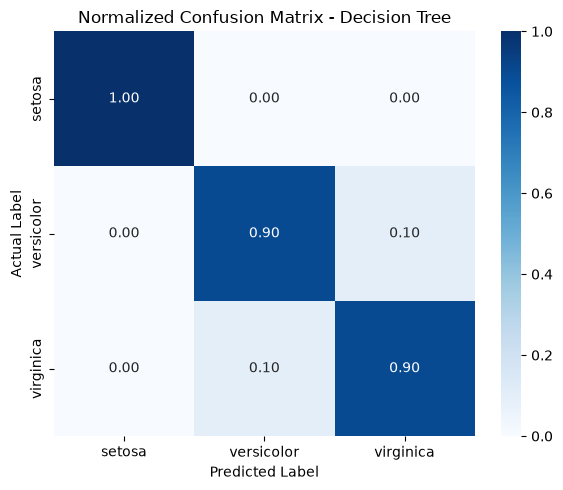

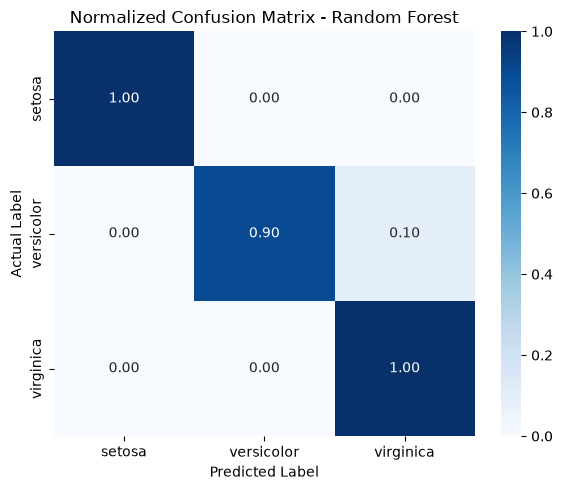

In [51]:
for name, model in final_models.items():

    y_pred = model.predict(x_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        normalize="true"
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=data.target_names,
        yticklabels=data.target_names
    )

    plt.title(f"Normalized Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

## 16. ROC-AUC Analysis

Receiver Operating Characteristic (ROC) curve and Area Under the Curve
(ROC-AUC) are used to evaluate the classification performance of the models.

Since the Iris dataset contains three classes, a One-vs-Rest (OvR) approach
is used to calculate the multiclass ROC-AUC score.

The macro-average ROC-AUC gives equal importance to all three Iris species.

A higher ROC-AUC value indicates better ability of the model to distinguish
between the different Iris species.

<Figure size 800x600 with 0 Axes>

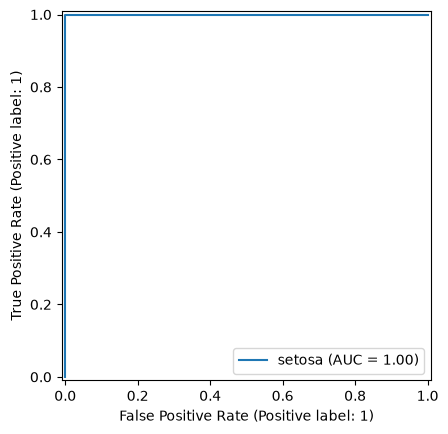

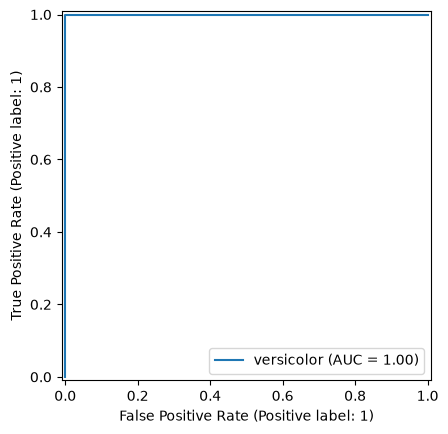

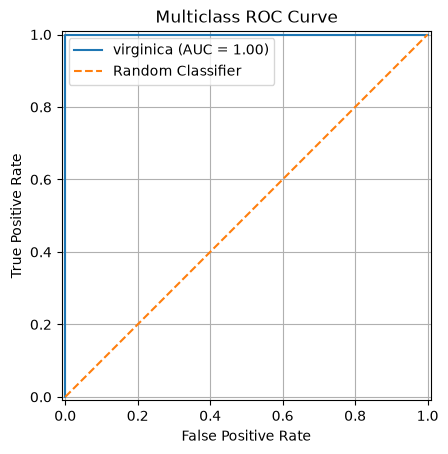

In [52]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

# Convert multiclass target into binary format
label_binarizer = LabelBinarizer()
y_test_bin = label_binarizer.fit_transform(y_test)

# Get probability predictions
final_model=grid_knn.best_estimator_
final_model.fit(x_train,y_train)
y_prob =final_model.predict_proba(x_test)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(data.target_names):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_prob[:, i],
        name=f"{class_name}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

## 17. Feature Importance

Feature importance is analyzed to understand which input features contribute
most to the predictions made by the Random Forest model.

The importance values indicate the relative contribution of each feature to
the model's decision-making process.

The four features analyzed are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Feature importance is used here for model interpretation and does not
determine the final model selection.

In [53]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the trained Random Forest model
rf_model = RandomForestClassifier()
rf_model.fit(x_train,y_train)

# Extract feature importance
importance = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
2,petal length (cm),0.446032
3,petal width (cm),0.403065
0,sepal length (cm),0.124227
1,sepal width (cm),0.026676


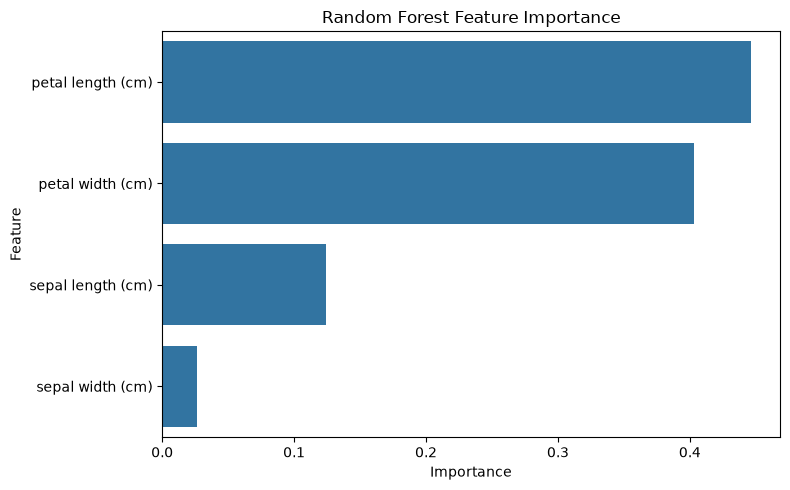

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 18. Final Model Selection

The tuned models are compared using their cross-validation and test-set
performance.

K-Nearest Neighbors (KNN) achieved the highest cross-validation F1-score of
**0.97497**.

KNN also achieved an F1-score of **1.00** on the test dataset. Logistic
Regression also achieved an F1-score of 1.00 on the test dataset, but its
cross-validation F1-score was lower at **0.96634**.

Based on the observed cross-validation and test-set results, KNN is selected
as the final model.

The selected KNN hyperparameters are:

- Number of Neighbors: 5
- Distance Metric: Euclidean
- Weighting: Uniform

In [67]:
final_results_df = pd.DataFrame(
    final_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

final_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KNN,1.000000,1.000000,1.000000,1.000000,1.000000
1,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
2,Decision Tree,0.933333,0.933333,0.933333,0.933333,0.973333
3,Random Forest,0.966667,0.969697,0.966667,0.966583,0.986667


In [ ]:
# Display final model comparison

final_model

## 19. Save Final Model

The selected KNN model is saved using Joblib so that it can be reused later
without retraining the model.

The complete trained KNN pipeline is saved as a `.pkl` file.

**Saved Model:** `iris_flower_classification_knn_model.pkl`

In [68]:
import joblib

# Select the final tuned KNN model
final_model = final_models["KNN"]

# Save the model
joblib.dump(final_model, "iris_flower_classifier.pkl")

print("Final KNN model saved successfully.")

Final KNN model saved successfully.


## 20. Load Saved Model

The saved KNN model is loaded using Joblib.

Loading the saved model allows predictions to be performed without repeating
the training and hyperparameter tuning process.

In [69]:
import joblib

loaded_model = joblib.load("iris_flower_classifier.pkl")

print("Model loaded successfully.")

Model loaded successfully.


## 21. Make Prediction

A sample Iris flower is provided using its four physical measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The saved KNN model uses these measurements to predict the corresponding Iris
species.

In [82]:
import pandas as pd

sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=data.feature_names
)

prediction = model.predict(sample)

print("Predicted class:", data.target_names[prediction[0]])

Predicted class: setosa


## 22. Prediction Probabilities

The saved KNN model provides prediction probabilities for the three Iris
species:

- Setosa
- Versicolor
- Virginica

The species with the highest predicted probability is selected as the final
prediction.

In [84]:
import pandas as pd

sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=data.feature_names
)

probabilities = model.predict_proba(sample)

for class_name, probability in zip(data.target_names, probabilities[0]):
    print(f"{class_name}: {probability:.2f}")

setosa: 1.00
versicolor: 0.00
virginica: 0.00


## 23. Conclusion

This project developed a machine learning classification system to identify
Iris flower species using sepal and petal measurements.

The project followed a complete machine learning workflow, including
exploratory data analysis, feature selection, train-test splitting, model
training, baseline evaluation, cross-validation, hyperparameter tuning, and
final model evaluation.

Four classification algorithms were evaluated: Logistic Regression,
K-Nearest Neighbors, Decision Tree, and Random Forest.

KNN achieved the highest cross-validation F1-score of **0.97497** and an
F1-score of **1.00** on the test dataset. Based on the observed
cross-validation and test-set performance, KNN was selected as the final
model.

The final trained model was saved as
`iris_flower_classification_knn_model.pkl` and can be reused for future
predictions without retraining.